In [ ]:
import joblib             as jlb
import matplotlib.pyplot  as plt
import warnings
import seaborn as sns
import pandas as pd
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from collections          import Counter
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from pyclustering.utils import timedcall
from data_processing import D

In [ ]:
#class Kmeans
import numpy as np
class KMEANS:
    def __init__(self,data,n_clusters,max_iters=300):
        self.data = data
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.labels=None
    def euclidean_distance(self,point1,point2):
        return np.linalg.norm(point1-point2,axis=2)
    def fit(self):
        X=self.data.values
        random_idx=np.random.choice(len(X),size=self.n_clusters,replace=False)
        centroids=X[random_idx]

        for _ in range(self.max_iters):
            distances=self.euclidean_distance(X[:,np.newaxis],centroids)

            labels=np.argmin(distances,axis=1)
            new_centroids=np.array([X[labels==i].mean(axis=0) for i in range(self.n_clusters)])
            if np.allclose(centroids,new_centroids):
                break
            centroids=new_centroids
        self.centroids=centroids
        self.labels=labels
        self.Inertia=np.sum(np.linalg.norm(X-centroids[labels],axis=1)**2)
    def get_centroids(self):
        return self.centroids
    def get_labels(self):
        return self.labels
    def get_Inertia(self):
        return self.Inertia
    

#kmeans fast build
def Kmeans_silhouette_analysis(data, k_range,print_scores=False):
    silhouette_scores = []
    for k in k_range:
        model = KMEANS(data,n_clusters=k)
        model.fit()
        #kmeans get labels

        silhouette_scores.append(silhouette_score(data, model.get_labels()))
        if print_scores:
            print(f'k={k}, Silhouette Score: {silhouette_score(data, model.get_labels()):.4f}')

    plt.figure(figsize=(8, 5))
    plt.plot(k_range, silhouette_scores, marker='o')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Analysis for CLARANS')
    plt.show()
def Kmeans_davies_bouldin_analysis(data, k_range,print_scores=False):
    db_scores = []
    for k in k_range:
        model = KMEANS(data,n_clusters=k)
        model.fit()
        db_scores.append(davies_bouldin_score(data, model.get_labels()))
        if print_scores:
            print(f'k={k}, Davies-Bouldin Score: {davies_bouldin_score(data, model.get_labels()):.4f}')

    plt.figure(figsize=(8, 5))
    plt.plot(k_range, db_scores, marker='o')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Davies-Bouldin Score')
    plt.title('Davies-Bouldin Analysis for CLARANS')
    plt.show()
def Kmeans_Inertia_analysis(data, k_range,print_scores=False):
    inertia_scores = []
    for k in k_range:
        model = KMEANS(data,n_clusters=k)
        model.fit()
        inertia_scores.append(model.get_Inertia())
        if print_scores:
            print(f'k={k}, Inertia: {model.get_Inertia():.4f}')

    plt.figure(figsize=(8, 5))
    plt.plot(k_range, inertia_scores, marker='o')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia')
    plt.title('Inertia Analysis for CLARANS')
    plt.show()

In [15]:
features=['Income','Age','Total_Spend']
data=D[features].copy()
print(data.shape)
print(data.head(1))

(2229, 3)
     Income       Age  Total_Spend
0  0.316484  1.015715     1.204332


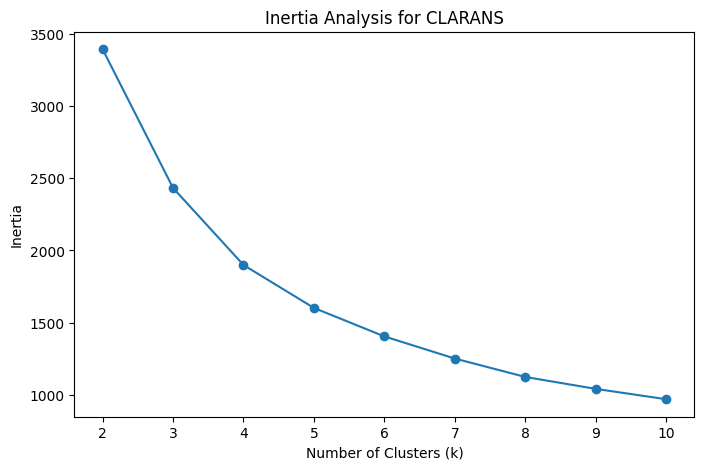

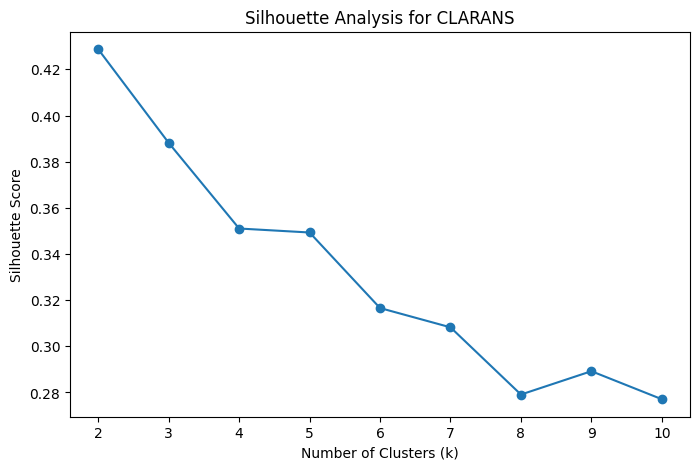

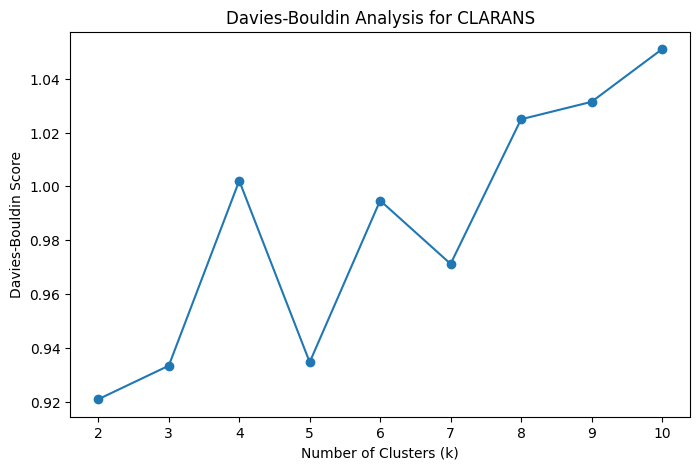

In [16]:
Kmeans_Inertia_analysis(data, k_range=range(2, 11))
Kmeans_silhouette_analysis(data, k_range=range(2, 11))
Kmeans_davies_bouldin_analysis(data, k_range=range(2, 11))

In [17]:
##------------------------------------------------------------------------------
## Xây dựng mô hình kMeans
##------------------------------------------------------------------------------
k     = 4
Kmeans_model = KMEANS(data,n_clusters = k)
(ticks,results) = timedcall(Kmeans_model.fit)  # xây dựng mô hình
print(f"Thời gian chạy: {ticks:.4f} giây")

Thời gian chạy: 0.0060 giây


In [18]:
## Lưu trữ mô hình để khai thác về sau
jlb.dump(Kmeans_model,'../customer_clustering/Output/kMeans.mdl')

['../customer_clustering/Output/kMeans.mdl']

In [19]:
## Khai thác mô hình đã được xây dựng
Loaded_Kmeans_model = jlb.load('../customer_clustering/Output/kMeans.mdl')

In [20]:
## Các trọng tâm
print(f'*** {k} trọng tâm:')
print(Loaded_Kmeans_model.get_centroids())

*** 4 trọng tâm:
[[ 0.7635684  -0.66815477  0.82763656]
 [-0.53771508  0.77866512 -0.63005403]
 [-1.04621443 -0.80140158 -1.06185864]
 [ 0.83226018  1.0499851   0.85687135]]


In [21]:
## Kết quả gom cụm khách hàng
centroids       = Loaded_Kmeans_model.get_centroids()
data['cluster'] = Loaded_Kmeans_model.get_labels()
print(data.head(5))
print('\nKích thước các clusters:', Counter(Loaded_Kmeans_model.get_labels()))
print('\nClusters lớn nhất:', Counter(Loaded_Kmeans_model.get_labels()).most_common(1))

     Income       Age  Total_Spend  cluster
0  0.316484  1.015715     1.204332        3
1 -0.256135  1.272020    -1.563480        1
2  0.970719  0.332234     0.703879        3
3 -1.212506 -1.291031    -1.115376        2
4  0.324010 -1.034726     0.289010        0

Kích thước các clusters: Counter({np.int64(2): 632, np.int64(0): 609, np.int64(3): 531, np.int64(1): 457})

Clusters lớn nhất: [(np.int64(2), 632)]


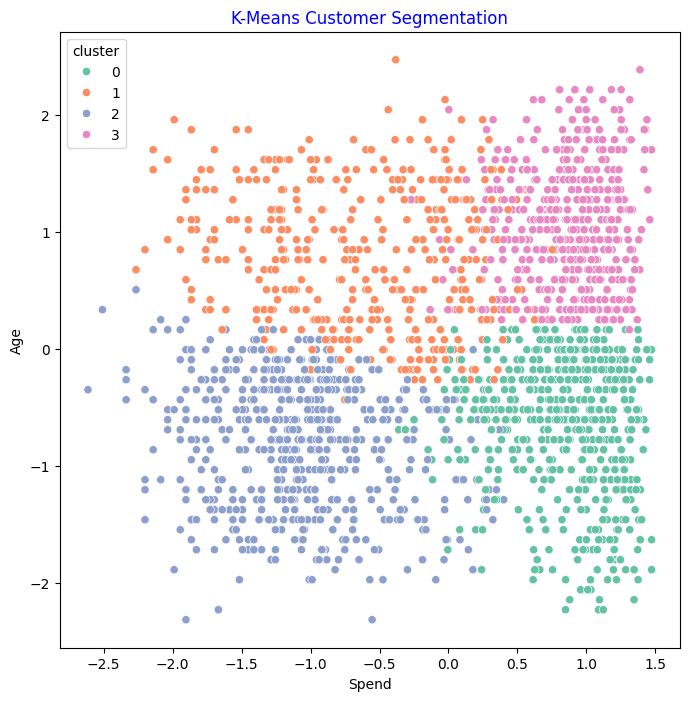

In [22]:
## Biểu diễn trực quan
plt.figure(figsize = (8, 8))
sns.scatterplot(
    x=data['Total_Spend'],
    y=data['Age'],
    hue=data['cluster'],palette="Set2"
)
plt.xlabel('Spend')
plt.ylabel('Age')
plt.title("K-Means Customer Segmentation", color = "blue")
plt.show()

In [23]:
pca=PCA(n_components=2)
pca.fit(data)
PCA_ds=pd.DataFrame(pca.transform(data),columns=(['col1','col2']))
print(PCA_ds.describe())

               col1          col2
count  2.229000e+03  2.229000e+03
mean   5.578510e-17 -1.267119e-16
std    1.383471e+00  1.268592e+00
min   -3.493982e+00 -2.678908e+00
25%   -1.260004e+00 -1.307466e+00
50%    2.082598e-01  1.140104e-01
75%    1.200212e+00  7.156176e-01
max    2.852316e+00  2.429505e+00


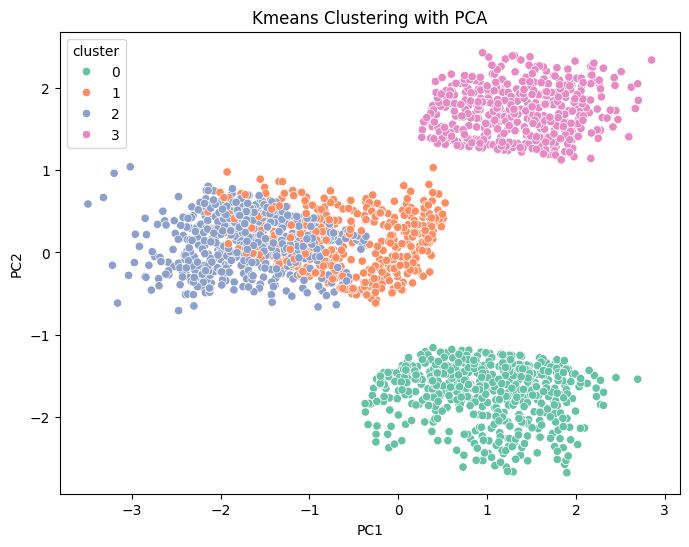

In [24]:

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=PCA_ds['col1'],
    y=PCA_ds['col2'],
    hue=data['cluster'],
    palette='Set2'
)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Kmeans Clustering with PCA')
plt.show()